In [1]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import root_mean_squared_error as RMSE
from statsmodels.tsa.arima.model import ARIMA


In [2]:
df=pd.read_csv("D:\\AshleshaRuchika\\PGCP-AI\\Machine Learning\\Datasets\\AusGas.csv")
df

,Month,GasProd
0,Jan-1956,1709
1,Feb-1956,1646
2,Mar-1956,1794
3,Apr-1956,1878
4,May-1956,2173
...,...,...
471,Apr-1995,49013
472,May-1995,56624
473,Jun-1995,61739
474,Jul-1995,66600


In [3]:
diff1=df['GasProd'].diff().iloc[1:]
result=adfuller(diff1,maxlag=10)
print("P-Value= ",result[1])
if result[1]<0.05:
    print("Time Series is Stationary")
else:
    print("Time Series is not Stationary")

P-Value=  2.151118858189121e-29
Time Series is Stationary


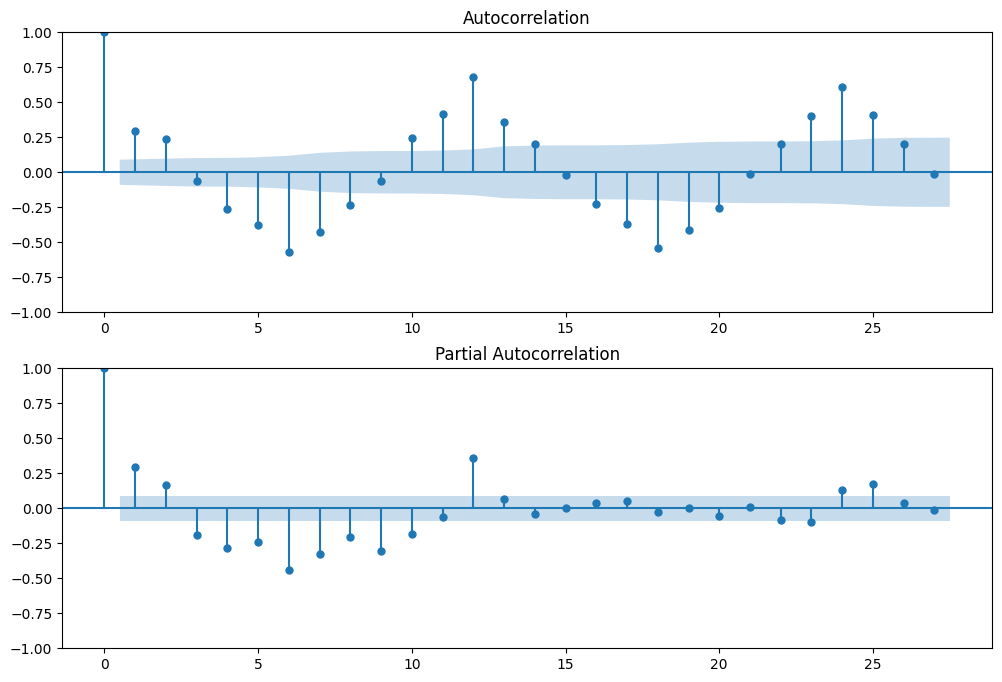

In [4]:
fig,ax=plt.subplots(2,1,figsize=(12,8))
plot_acf(diff1,ax=ax[0])
plot_pacf(diff1,ax=ax[1])
plt.show()

In [5]:
y_train=df['GasProd'].iloc[:-12]
y_test=df['GasProd'].iloc[-12:]

In [6]:
model=ARIMA(y_train,order=(1,1,2))
model_fit=model.fit()
print('Coefficients: %s'% model_fit.params)

Coefficients: ar.L1     7.765128e-01
ma.L1    -6.680617e-01
ma.L2    -2.525748e-01
sigma2    6.249294e+06
dtype: float64


In [7]:
predictions=model_fit.predict(start=len(y_train),end=len(y_train)+len(y_test)-1,dynamic=False)
RMSE(y_test,predictions)

10304.744936045687

In [8]:
df=pd.read_csv("D:\\AshleshaRuchika\\PGCP-AI\\Machine Learning\\Datasets\\monthly-milk-production-pounds-p.csv")
df

,Month,Milk
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727
...,...,...
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797


In [9]:
diff1=df['Milk'].diff().iloc[1:]
result=adfuller(diff1,maxlag=10)
print("P-Value= ",result[1])
if result[1]<0.05:
    print("Time Series is Stationary")
else:
    print("Time Series is not Stationary")

P-Value=  0.0
Time Series is Stationary


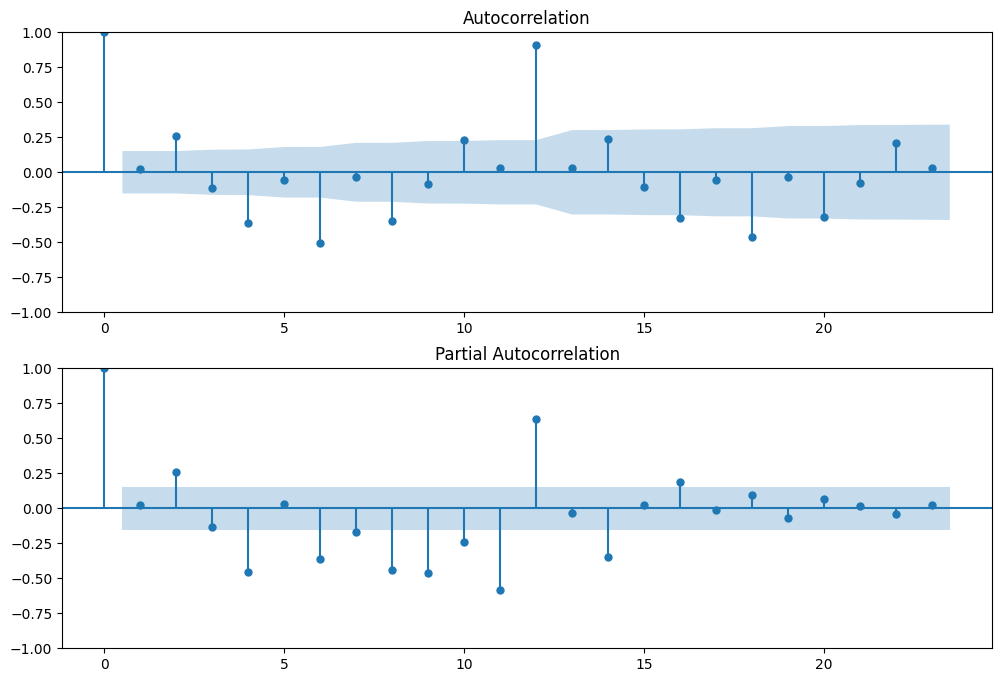

In [10]:
fig,ax=plt.subplots(2,1,figsize=(12,8))
plot_acf(diff1,ax=ax[0])
plot_pacf(diff1,ax=ax[1])
plt.show()

In [11]:
y_train=df['Milk'].iloc[:-12]
y_test=df['Milk'].iloc[-12:]

In [12]:
model=ARIMA(y_train,order=(1,1,2))
model_fit=model.fit()
print('Coefficients: %s'% model_fit.params)

Coefficients: ar.L1       -0.216067
ma.L1        0.282827
ma.L2        0.491660
sigma2    1712.400405
dtype: float64


In [13]:
predictions=model_fit.predict(start=len(y_train),end=len(y_train)+len(y_test)-1,dynamic=False)
RMSE(y_test,predictions)

70.72177321735741

NameError: name 'fcast1' is not defined

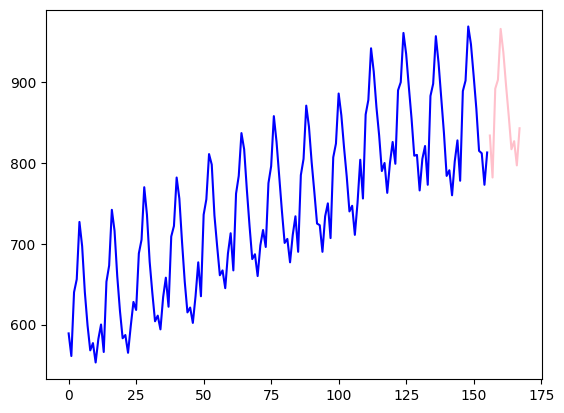

In [14]:
y_train.plot(color='blue',label='Train')
y_test.plot(color='pink', label='Test')
# rmse=np.round(RMSE(y_test,fcast1),2)
# plt.text(100,600,f'RMSE={rmse}')
# fcast1.plot(color='purple',label='Forecast')
# plt.legend(loc='best')
# plt.show()